RFM Table

In [1]:
import pandas as pd

orders = pd.read_csv(
    "Datasets/orders.csv"
)

orders["order_timestamp"] = pd.to_datetime(
    orders["order_timestamp"]
)

snapshot_date = (
    orders["order_timestamp"].max()
    + pd.Timedelta(days=1)
)

rfm = orders.groupby("user_id").agg(
{
    "order_timestamp": lambda x:
        (
            snapshot_date - x.max()
        ).days,

    "order_id":"count",

    "revenue":"sum"
}
)

rfm.columns = [
    "Recency",
    "Frequency",
    "Monetary"
]

rfm.head()

C:\Users\HP\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\HP\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


,Recency,Frequency,Monetary
user_id,,,
1,108,1,5798.40
3,42,1,20150.10
4,107,2,17721.90
5,7,2,9969.85
7,102,1,1149.60


RFM Scores

In [2]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5,4,3,2,1]
)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(
        method="first"
    ),
    5,
    labels=[1,2,3,4,5]
)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    5,
    labels=[1,2,3,4,5]
)

rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str)
    +
    rfm["F_Score"].astype(str)
    +
    rfm["M_Score"].astype(str)
)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
user_id,,,,,,,
1,108,1,5798.40,1,1,2,112
3,42,1,20150.10,4,1,3,413
4,107,2,17721.90,2,3,3,233
5,7,2,9969.85,5,3,3,533
7,102,1,1149.60,2,1,1,211


Customer Segments

In [3]:
def segment(row):

    if row["RFM_Score"] in [
        "555",
        "554",
        "545"
    ]:
        return "Champions"

    elif row["F_Score"] >= 4:
        return "Loyal"

    elif row["R_Score"] >= 4:
        return "Potential Loyalist"

    elif row["R_Score"] <= 2:
        return "At Risk"

    else:
        return "Others"

rfm["Segment"] = rfm.apply(
    segment,
    axis=1
)

rfm["Segment"].value_counts()

Segment
At Risk               1117
Loyal                 1100
Potential Loyalist     563
Others                 380
Champions              274
Name: count, dtype: int64

Visual Plot

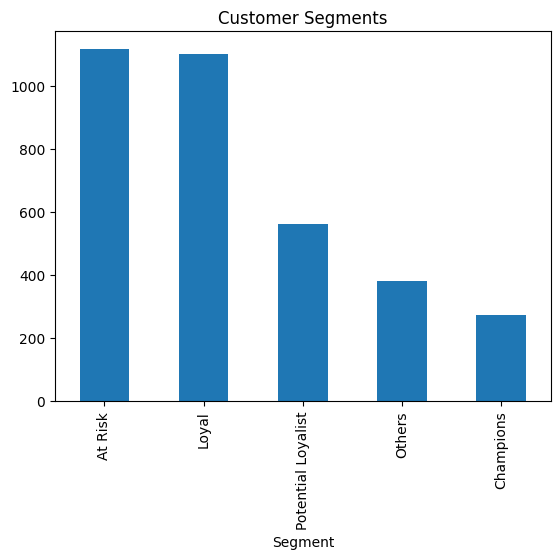

In [4]:
import matplotlib.pyplot as plt

rfm["Segment"].value_counts().plot(
    kind="bar"
)

plt.title(
    "Customer Segments"
)

plt.show()

# CHURN PREDICTION

Lable Creation

In [5]:
snapshot_date = (
    orders["order_timestamp"].max()
    + pd.Timedelta(days=1)
)

customer_features = orders.groupby(
    "user_id"
).agg({

    "order_timestamp":
        lambda x:
        (
            snapshot_date -
            x.max()
        ).days,

    "order_id":"count",

    "revenue":"sum"

})

customer_features.columns = [
    "days_since_last_purchase",
    "num_orders",
    "total_revenue"
]

customer_features["churn"] = (
    customer_features[
        "days_since_last_purchase"
    ] > 30
).astype(int)

customer_features.head()

,days_since_last_purchase,num_orders,total_revenue,churn
user_id,,,,
1,108,1,5798.40,1
3,42,1,20150.10,1
4,107,2,17721.90,1
5,7,2,9969.85,0
7,102,1,1149.60,1


Model Training

In [6]:
from sklearn.model_selection import (
    train_test_split
)

from sklearn.ensemble import (
    RandomForestClassifier
)

from sklearn.metrics import (
    classification_report
)

X = customer_features[
[
    "days_since_last_purchase",
    "num_orders",
    "total_revenue"
]
]

y = customer_features["churn"]

X_train,X_test,y_train,y_test = (
    train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

preds = model.predict(
    X_test
)

print(
    classification_report(
        y_test,
        preds
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       187
           1       1.00      1.00      1.00       500

    accuracy                           1.00       687
   macro avg       1.00      1.00      1.00       687
weighted avg       1.00      1.00      1.00       687



Feature Importance

In [7]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":
    model.feature_importances_

})

importance.sort_values(
    "Importance",
    ascending=False
)

,Feature,Importance
0,days_since_last_purchase,0.918344
1,num_orders,0.059216
2,total_revenue,0.022441


CLTV Analysis

In [8]:
cltv = orders.groupby(
    "user_id"
)["revenue"].sum()

cltv.describe()

count      3434.000000
mean      47388.148457
std       72774.160541
min         108.300000
25%        4939.050000
50%       14435.325000
75%       56909.150000
max      567550.700000
Name: revenue, dtype: float64

In [9]:
rfm.to_csv(
    "rfm_segments.csv"
)

In [10]:
customer_features.to_csv(
    "customer_features.csv"
)